In [7]:
import numpy as np
from IPython import get_ipython
from PIL.Image import fromarray


def display_np_arrays_as_images():
    def np_to_png(a):
        if 2 <= len(a.shape) <= 3:
            return fromarray(np.array(np.clip(a, 0, 1) * 255, dtype="uint8"))._repr_png_()
        else:
            return fromarray(np.zeros([1, 1], dtype="uint8"))._repr_png_()

    def np_to_text(obj, p, cycle):
        if len(obj.shape) < 2:
            print(repr(obj))
        if 2 <= len(obj.shape) <= 3:
            pass
        else:
            print(f"<array of shape {obj.shape}>")

    get_ipython().display_formatter.formatters["image/png"].for_type(np.ndarray, np_to_png)
    get_ipython().display_formatter.formatters["text/plain"].for_type(np.ndarray, np_to_text)


display_np_arrays_as_images()

In [10]:
ims = np.load("./test_images.npy")
ims.shape, ims.dtype

((6, 96, 96, 3), dtype('float64'))

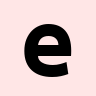

In [16]:
from einops import rearrange, reduce, repeat

ims[0]

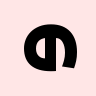

In [ ]:
# Transpose image.
rearrange(ims[0], "h w c -> w h c")

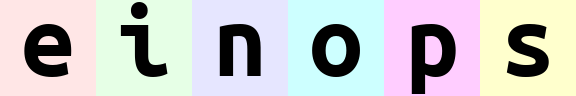

In [ ]:
rearrange(ims, "b h w c -> (b h) w c")
rearrange(ims, "b h w c -> h (b w) c")

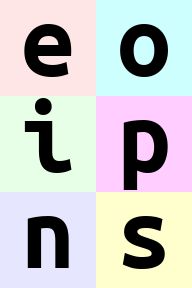

In [22]:
rearrange(ims, "(b1 b2) h w c -> (b2 h) (b1 w) c", b1 = 2)

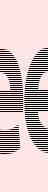

In [ ]:
rearrange(ims[0], "h (w2 w) c -> (h w2) w c", w2=2)

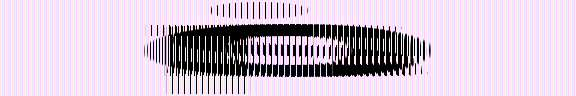

In [33]:
rearrange(ims, "b h w c ->  h (w b) c")

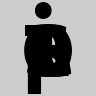

In [38]:
reduce(ims, "b h w c -> h w c", "min")

In [47]:
# max-pooling
_ims = ims
for i in range(2):
    _ims = reduce(_ims, "b (h h2) (w w2) c -> b h w c", "max", h2=2, w2=2)
rearrange(_ims, "b h w c -> h (b w) c")

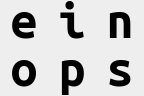

In [52]:
# average-pooling
reduce(ims, "(b1 b2) (h h2) (w w2) c -> (b1 h) (b2 w)", "mean", b1=2, h2=2, w2=2)

In [65]:
x = list(ims)
rearrange(x, "b h w c -> h w (b c)").shape

(96, 96, 18)

In [68]:
x = rearrange(ims, "b h w c -> b h 1 w 1 c")
x.shape
rearrange(x, "b h 1 w 1 c -> b h w c")

<array of shape (6, 96, 96, 3)>


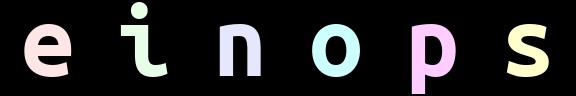

In [69]:
x = reduce(ims, "b h w c -> b 1 1 c", "max") - ims
rearrange(x, "b h w c -> h (b w) c")

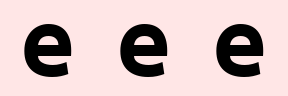

In [70]:
repeat(ims[0], "h w c -> h (rep w) c", rep=3)

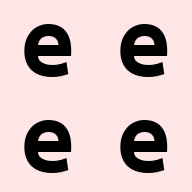

In [72]:
repeat(ims[0], "h w c -> (2 h) (2 w) c")

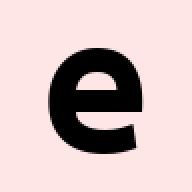

In [81]:
repeat(ims[0], "h w c -> (h 2) (w 2) c")

In [82]:
repeated = repeat(ims[0], "h w c -> h rep w c", rep=3)
reduced = reduce(repeated, "h rep w c -> h w c", "min")
np.array_equal(ims[0], reduced)

True

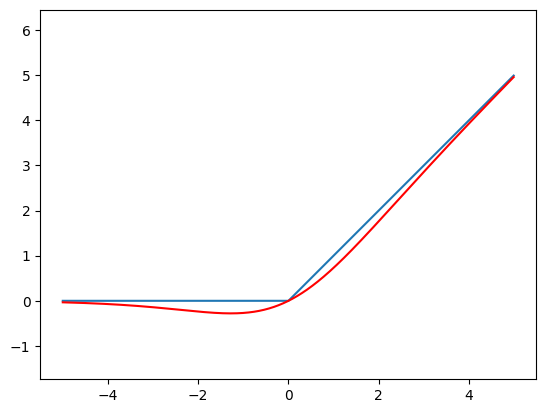

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

silu = lambda x: x / (1 +  np.exp(-x))
relu = lambda x: x * (x > 0)

x = np.arange(-5, 5, 0.01)

y = relu(x)
plt.axis("equal")
plt.plot(x, y)

y = silu(x)
plt.plot(x, y, "red")


In [19]:
from dataclasses import dataclass


@dataclass
class Config:
    vocab_size: int
    ctx_len: int
    num_layers: int
    d_model: int
    num_heads: int
    d_ff: int


def num_params(c: Config):
    count = 0

    count += c.vocab_size * c.d_model  # Embedding table

    for i in range(c.num_layers):
        count += 2 * c.d_model  # 2 pre-RMSNorms
        count += 4 * c.d_model**2  # QKV + out proj weight
        count += 3 * c.d_ff * c.d_model  # ffn with swiglu

    count += c.d_model  # last RMSNorm of attn output
    count += c.vocab_size * c.d_model  # LM head proj
    return count


metadata = {}

metadata["gpt2_xl"] = Config(
    vocab_size=50257,
    ctx_len=1024,
    num_layers=48,
    d_model=1600,
    num_heads=25,
    d_ff=6400,
)


nparams = num_params(metadata["gpt2_xl"])
print(
    f"gpt2-xl: {nparams / 10**9:.2f}B params",
    f"of size {nparams * 4 / (1024**3):.2f}GB in float32",
)


gpt2-xl: 2.13B params of size 7.92GB in float32
